In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
PATH_TO_FILES = 'C:/GIT_REPOS/SCT/COSY/src' 

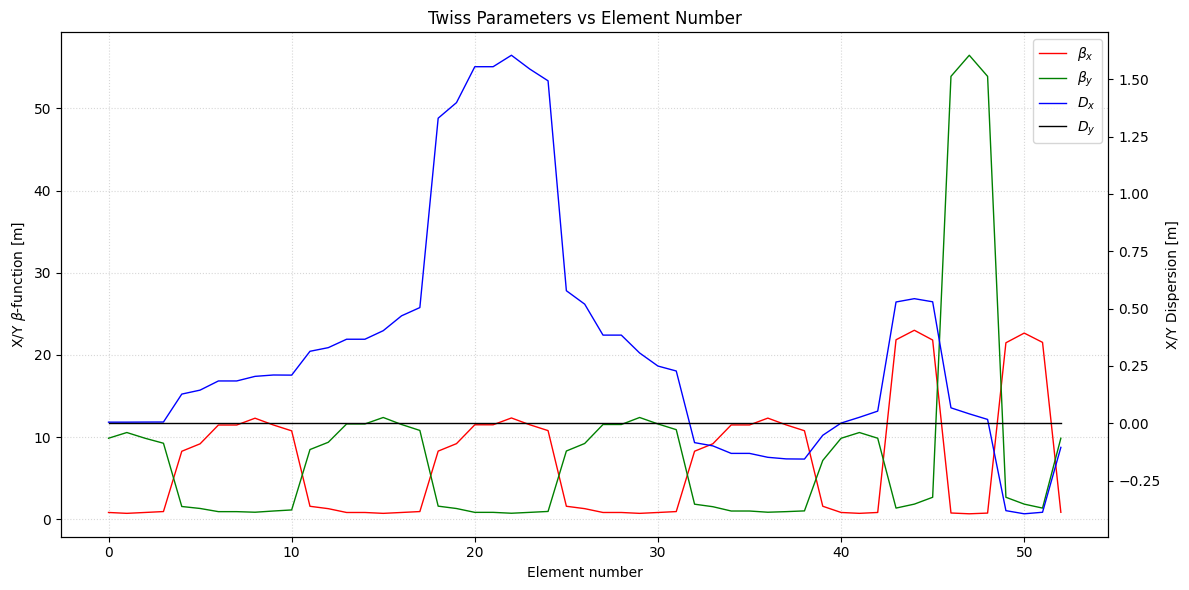

In [3]:
files_to_plot = {
    'BETAX': {'ax': 'left',  'color': 'red',   'label': r'$\beta_x$'},
    'BETAY': {'ax': 'left',  'color': 'green', 'label': r'$\beta_y$'},
    'DISPX': {'ax': 'right', 'color': 'blue',  'label': r'$D_x$'},
    'DISPY': {'ax': 'right', 'color': 'black', 'label': r'$D_y$'}
}

fig, ax_left = plt.subplots(figsize=(12, 6))
ax_right = ax_left.twinx()
found = False

for filename, cfg in files_to_plot.items():
    full_path = os.path.join(PATH_TO_FILES, filename)
    
    if os.path.exists(full_path):
        try:
            # Read file skipping header, using raw string for regex separator
            df = pd.read_csv(full_path, sep=r'\s+', header=None, skiprows=1)
            
            # Convert first column (index 0) to numeric values
            y_values = pd.to_numeric(df[0], errors='coerce').dropna()
            
            ax = ax_left if cfg['ax'] == 'left' else ax_right
            # Plot using element index as X-axis, lw=1 for thin lines
            ax.plot(y_values.index, y_values.values, label=cfg['label'], color=cfg['color'], lw=1)
            found = True
        except Exception as e:
            print(f"Error in file {filename}: {e}")
    else:
        print(f"File {filename} not found")

if found:
    # English labels and titles
    ax_left.set_xlabel('Element number')
    ax_left.set_ylabel(r'X/Y $\beta$-function [m]')
    ax_right.set_ylabel(r'X/Y Dispersion [m]')
    
    # Merging legends from both axes
    h1, l1 = ax_left.get_legend_handles_labels()
    h2, l2 = ax_right.get_legend_handles_labels()
    ax_left.legend(h1 + h2, l1 + l2, loc='upper right')
    
    plt.title('Twiss Parameters vs Element Number')
    ax_left.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No data found. Please check PATH_TO_FILES and file names.")

In [4]:
fig.savefig('twiss_plot.png', dpi=300, bbox_inches='tight')
fig.savefig('twiss_plot.pdf', bbox_inches='tight')

print(f"Plot saved successfully to {os.getcwd()}")

Plot saved successfully to C:\GIT_REPOS\SCT\COSY\analysis
